In [1]:
import json
import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

from connectivity.curves import CURVES


%load_ext autoreload
%autoreload 2
%aimport connectivity


C:\Users\E1024679\AppData\Local\Temp\ipykernel_19688\4025652313.py:75: UserWarning: Rasterization of '<matplotlib.collections.PathCollection object at 0x0000022CC7F3F140>' will be ignored
  coll.set_rasterized(True)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_19688\4025652313.py:75: UserWarning: Rasterization of '<matplotlib.collections.PathCollection object at 0x0000022CC72DBB00>' will be ignored
  coll.set_rasterized(True)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_19688\4025652313.py:75: UserWarning: Rasterization of '<matplotlib.collections.PathCollection object at 0x0000022CC5C3D1F0>' will be ignored
  coll.set_rasterized(True)


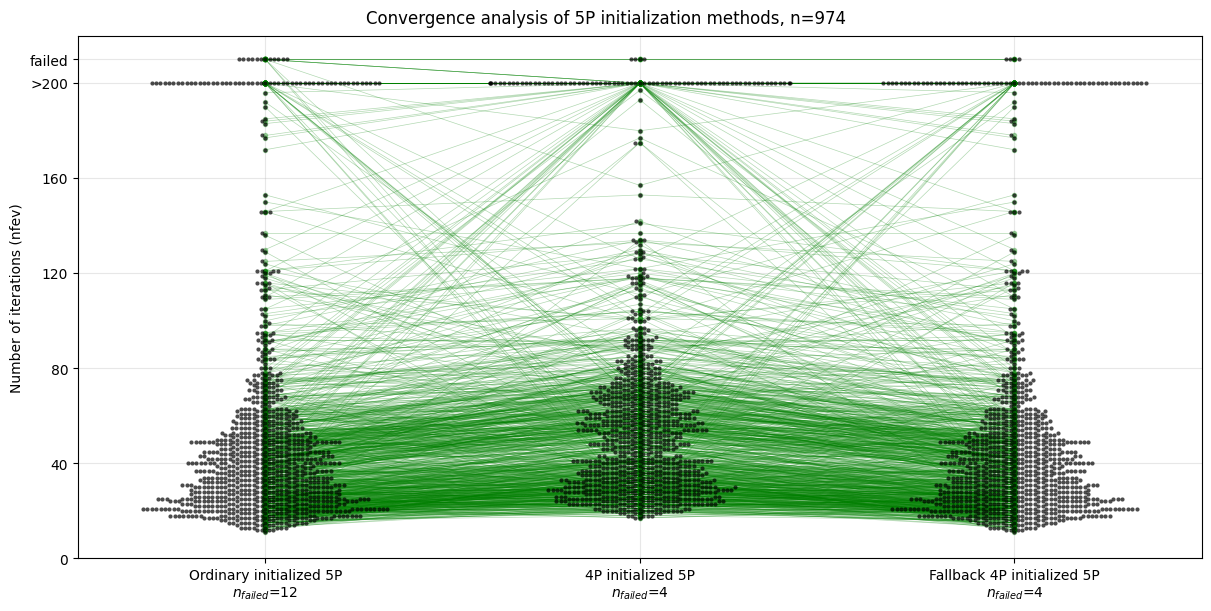

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

convergence_analysis_df = pd.read_json("../output/convergence_analysis/convergence_analysis_lf.json")
curve_fitting_df = pd.read_json("../output/curve_fitting/curve_fitting_lf.json")

convergence_analysis_df = convergence_analysis_df.merge(curve_fitting_df,
    on=["patient_id", "stim_channel_name", "response_channel_name"])

#convergence_analysis_df["combined"] = convergence_analysis_df["Ordinary_init_linear_5P_nfev"] + convergence_analysis_df["4P_init_linear_5P_nfev"]

# for failing 5P fits, use 4P nfev + 4P_init_linear_5P_nfev


#convergence_analysis_df["4Pcorr_init_linear_5P_nfev"] = convergence_analysis_df["4P_init_linear_5P_nfev"]

# ordinary 4P init
mask = (convergence_analysis_df["4P_init_linear_5P_nfev"] != -1) & (convergence_analysis_df["4P_nfev"] != -1)
convergence_analysis_df.loc[mask, "4P_init_linear_5P_nfev"] += convergence_analysis_df.loc[mask, "4P_nfev"]

# fallback 4P init
# if 5P == -1 -> add 4P nfev if not =-1
convergence_analysis_df["Fallback_4P_init_linear_5P_nfev"] = convergence_analysis_df["Ordinary_init_linear_5P_nfev"]
convergence_analysis_df.loc[
    (convergence_analysis_df["Ordinary_init_linear_5P_nfev"] == -1) &
    (convergence_analysis_df["4P_init_linear_5P_nfev"] != -1),
    "Fallback_4P_init_linear_5P_nfev"
] = convergence_analysis_df["4P_init_linear_5P_nfev"] + 20000 # 20000 for failed 5P 


initial_value_names = ["Ordinary", "4P", "Fallback_4P"]
LOSSES = ["linear"] #,"soft_l1"]

nfev_cols = []
friendly_names = []
for loss in LOSSES:
    for init_name in initial_value_names:
        col_name = f"{init_name}_init_{loss}_5P_nfev"
        nfev_cols.append(col_name)
        if init_name == "Fallback_4P":
            friendly_names.append(f"Fallback 4P initialized 5P" + "\n$n_{failed}$=" + f"{len(convergence_analysis_df[convergence_analysis_df[col_name] == -1])}") # +{loss}")
        else:
            friendly_names.append(f"{init_name} initialized 5P" + "\n$n_{failed}$=" + f"{len(convergence_analysis_df[convergence_analysis_df[col_name] == -1])}") # +{loss}")
x_positions = range(len(nfev_cols))
#nfev_cols.append("combined")
convergence_analysis_df[nfev_cols] = convergence_analysis_df[nfev_cols].clip(upper=200)
convergence_analysis_df[nfev_cols] = convergence_analysis_df[nfev_cols].replace(-1, 210)


plt.figure(figsize=(12, 6), constrained_layout=True)

# --- Plot all runs as thin lines ---
for _, row in convergence_analysis_df.iterrows():
    plt.plot(
        x_positions,
        row[nfev_cols],
        color="green",
        alpha=0.3,
        linewidth=0.5,
        marker="o",
        markersize=3
    )

# --- Overlay a strip plot for distribution clarity ---
sns.swarmplot(
    data=convergence_analysis_df[nfev_cols],
    size=3,
    alpha=0.7,
    color="black"      # contrast color for aggregate distribution
)
# make it rasterized
ax = plt.gca()
for coll in ax.collections:
    coll.set_rasterized(True)

plt.ylabel("Number of iterations (nfev)")
plt.xticks(x_positions, friendly_names, ha="center")
plt.ylim(0, 220)
plt.yticks(list(range(0, 201, 40)) + [210], labels=[0, 40, 80, 120, 160, ">200", "failed"])
plt.grid(True, alpha=0.3)
plt.suptitle(f"Convergence analysis of 5P initialization methods, n={len(convergence_analysis_df)}")


plt.savefig("../output/figures/sfigure4.pdf", bbox_inches='tight', dpi=300)
plt.savefig("../output/figures/sfigure4.svg", bbox_inches='tight', dpi=300)

plt.show()